In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [2]:
labels = pd.read_csv('/data/archief/AMC-data/Barrett/LANS/lans_train_labels_with_ind.csv')
cons = labels[["block_id", "dx"]]
cons = cons[["block_id", "dx"]].replace({1: 0, 2: np.nan, 3: 1, 4: 2})
cons = cons.dropna(subset=["dx"])


In [3]:
rater_labels = labels.loc[:,"p53":]
rater_labels = rater_labels.drop(["p53"], axis=1).replace({1: 0, 2: np.nan, 3: 1, 4: 2})
rater_labels = pd.concat([labels["block_id"], rater_labels], axis=1)

In [4]:
rater_labels.iloc[:,1]

0       0.0
1       0.0
2       0.0
3       0.0
4       1.0
       ... 
1876    0.0
1877    0.0
1878    0.0
1879    0.0
1880    0.0
Name: MV HE + p53, Length: 1881, dtype: float64

In [14]:
basis = {}
results = {}
acc_individual = []
acc_consensus = []
difference = []

for path in range(1, 21):
    for fold in range (1, 6):
        df = pd.read_csv(f'../../../experiments/convmetrics_Pathologist_{path}_fold_{fold}/results.csv')
        basis[(path, fold, "df")] = df
        basis[(path, fold, "individual_labels")] = rater_labels[rater_labels["block_id"].isin(df["block_id"])].iloc[:,path].reset_index(drop=True)
        basis[(path, fold, "predictions")] = df["pred_class"]
        basis[(path, fold, "consensus_labels")] = cons[cons["block_id"].isin(df["block_id"])]["dx"].reset_index(drop=True)
        #remark: no particular reason for both dict AND list, just the iteration of implementations
        results[(path, fold, "accuracy_individual")] = accuracy_score(
            basis[(path, fold, "individual_labels")],
            basis[(path, fold, "predictions")]
        )
        acc_individual.append(results[(path, fold, "accuracy_individual")])
        results[(path, fold, "accuracy_consensus")] = accuracy_score(
            basis[(path, fold, "consensus_labels")],
            basis[(path, fold, "predictions")]
        )
        acc_consensus.append(results[(path, fold, "accuracy_consensus")])
        results[(path, fold, "difference")] = results[(path, fold, "accuracy_consensus")] - results[(path, fold, "accuracy_individual")]
        difference.append(results[(path, fold, "difference")])

In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
normalized_difference = scaler.fit_transform(difference.reshape(-1, 1))
normalized_difference

array([[0.61270403],
       [0.84437744],
       [0.67889643],
       [0.87747364],
       [0.64642078],
       [0.52720551],
       [0.48838266],
       [0.54651163],
       [0.64339323],
       [0.7015222 ],
       [0.69370744],
       [0.69370744],
       [0.60538995],
       [0.54651163],
       [0.78333333],
       [0.54651163],
       [0.81745171],
       [0.59166831],
       [0.59205426],
       [0.77422481],
       [0.47639994],
       [0.26606487],
       [0.54651163],
       [0.26606487],
       [0.4044186 ],
       [0.24202658],
       [0.62263289],
       [0.3942691 ],
       [0.54651163],
       [0.6237361 ],
       [0.46698195],
       [0.62604131],
       [0.70676692],
       [0.34619252],
       [0.38625634],
       [0.33337209],
       [0.54651163],
       [0.54651163],
       [0.54651163],
       [0.76853198],
       [0.48153006],
       [0.2216038 ],
       [0.67647476],
       [0.80643789],
       [0.74386305],
       [0.5144123 ],
       [0.48231297],
       [0.546

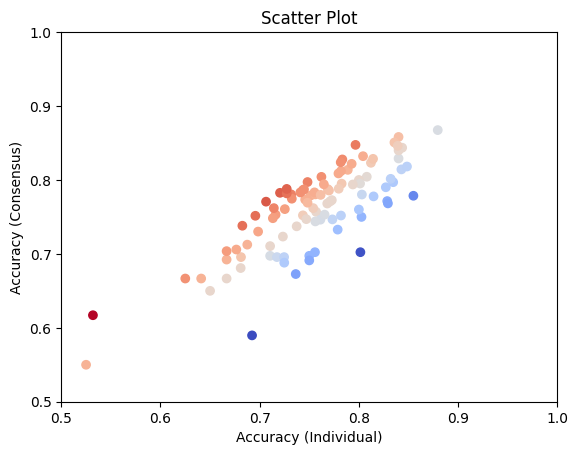

In [25]:
import matplotlib.pyplot as plt

plt.scatter(acc_individual, acc_consensus, c=normalized_difference, cmap="coolwarm")
plt.xlabel("Accuracy (Individual)")
plt.ylabel("Accuracy (Consensus)")
plt.ylim(0.5, 1)
plt.xlim(0.5, 1)
plt.title("Scatter Plot")
plt.show()
